# ClearSight 2.0: The State-of-the-Art Upgrade
Welcome to the new, upgraded pipeline. In this notebook, we are replacing the 2015 Google FaceNet (MTCNN) with the 2024 industry standards: **RetinaFace** (for detection) and **ArcFace** (for verification).

These are the models used by real-world police and security agencies today.

## Phase 1: Importing the New AI Libraries
We are using `deepface`, which acts as a wrapper for multiple massive AI models (including ArcFace and RetinaFace).

In [1]:
import cv2
import matplotlib.pyplot as plt
from deepface import DeepFace
import numpy as np

print("DeepFace, RetinaFace, and ArcFace modules are ready.")

c:\Users\rajti\raj123\envs\clearsight\lib\site-packages\mtcnn\mtcnn.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


DeepFace, RetinaFace, and ArcFace modules are ready.


## Phase 2: The New Detective (RetinaFace)
In the old pipeline, MTCNN would fail if a face turned sideways or was blurry. 

**RetinaFace** uses feature-pyramid networks. It can detect faces even if they are 70% occluded by objects or turned 90 degrees away from the camera. Let's load the Messi image and test it.

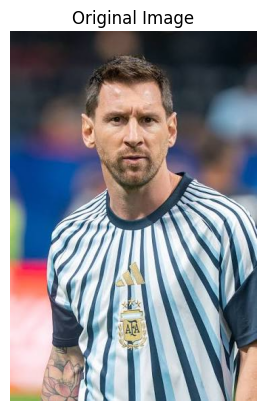

In [2]:
# Load the target image using ABSOLUTE path
image_path = 'C:/Users/rajti/Downloads/messi1.jpg'
img = cv2.imread(image_path)
if img is None:
    print("Error: Image not found at path:", image_path)
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title('Original Image')
    plt.show()

Scanning with RetinaFace...


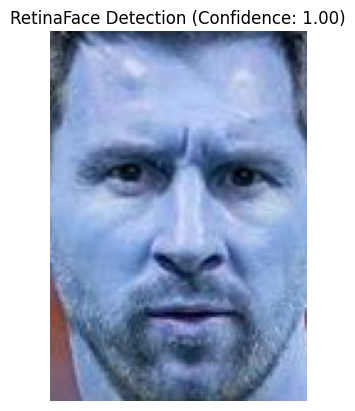

In [3]:
# Use RetinaFace to extract the face
if img is not None:
    print("Scanning with RetinaFace...")
    faces = DeepFace.extract_faces(img_path = img_rgb, detector_backend = 'retinaface', enforce_detection=False)
    for face_obj in faces:
        face_matrix = face_obj['face']
        confidence = face_obj['confidence']
        
        plt.imshow(face_matrix)
        plt.axis('off')
        plt.title(f'RetinaFace Detection (Confidence: {confidence:.2f})')
        plt.show()

## Phase 3: The New Mathematician (ArcFace)
In the old pipeline, **FaceNet** used *Triplet Loss* (measuring the physical distance between two faces in a 512D graph). Blurry lighting ruins physical distance, causing false positives.

**ArcFace** uses *Additive Angular Margin Loss*. Instead of measuring physical distance, it calculates the strict geometric **angle** of the face (cheekbones, eyes, nose). Because angles do not change in the dark, it is mathematically immune to bad lighting.

In [4]:
if img is not None:
    print("Generating ArcFace Embedding (The Mathematical Password)...")
    embedding_objs = DeepFace.represent(img_path = img_rgb, model_name = 'ArcFace', detector_backend = 'retinaface', enforce_detection=False)
    arcface_vector = embedding_objs[0]['embedding']
    
    print(f"ArcFace generated a highly-secure vector with {len(arcface_vector)} dimensions.")
    print("First 10 dimensions of the geometric angle:", arcface_vector[:10])

Generating ArcFace Embedding (The Mathematical Password)...
ArcFace generated a highly-secure vector with 512 dimensions.
First 10 dimensions of the geometric angle: [-0.13519378006458282, -0.02087138593196869, 0.001222791150212288, 0.15804895758628845, 0.08766993880271912, 0.06423595547676086, 0.1339886486530304, 0.05546800419688225, 0.18595650792121887, -0.05355048179626465]


## Phase 4: Zero-Shot Cosine Verification
Now we will compare two photos of Messi using **Cosine Similarity** (which checks the angle between the two vectors). If the Cosine Similarity is > 0.68, it is identical. If it's < 0.50, it is a random stranger.

In [5]:
def verify_identities(img1_path, img2_path):
    print(f"Comparing {img1_path} and {img2_path}...")
    result = DeepFace.verify(
        img1_path=img1_path, 
        img2_path=img2_path, 
        model_name='ArcFace', 
        detector_backend='retinaface', 
        distance_metric='cosine',
        enforce_detection=False
    )
    
    match = result['verified']
    distance = result['distance']  # For Cosine, lower distance = higher similarity
    threshold = result['threshold']
    
    print(f"MATCH FOUND? {match}")
    print(f"Cosine Distance: {distance:.3f} (Must be lower than {threshold:.3f})")

try:
    # Using absolute paths to ensure OpenCV can find them anywhere on your PC
    verify_identities('C:/Users/rajti/Downloads/messi1.jpg', 'C:/Users/rajti/Downloads/messi2.jpg')
except Exception as e:
    print("Error:", e)

Comparing C:/Users/rajti/Downloads/messi1.jpg and C:/Users/rajti/Downloads/messi2.jpg...
MATCH FOUND? True
Cosine Distance: 0.465 (Must be lower than 0.680)


## Phase 5: Live Video Tracking (The Frame-by-Frame Loop)
Now that we proved ArcFace works mathematically, let's unleash it on the video.
Instead of using a buggy OpenCV CSRT Tracker, we will calculate the ArcFace math on **every single frame** so it never drifts to the wrong person!

In [6]:
from scipy.spatial.distance import cosine
import cv2

MASTER_IMAGE = 'C:/Users/rajti/Downloads/messi1.jpg'
VIDEO_INPUT = 'C:/Users/rajti/Downloads/messivideo.mp4'
VIDEO_OUTPUT = 'C:/Users/rajti/Downloads/messivideo_tracked.mp4'
THRESHOLD = 0.68  # ArcFace Cosine Threshold

print("Step 1: Generating Master Vector for Messi...")
master_objs = DeepFace.represent(img_path=MASTER_IMAGE, model_name='ArcFace', detector_backend='retinaface')
master_vector = master_objs[0]['embedding']
print(f"Master Vector Locked. Dimension: {len(master_vector)}")

cap = cv2.VideoCapture(VIDEO_INPUT)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(VIDEO_OUTPUT, fourcc, fps, (width, height))

print(f"Step 2: Scanning Video ({total_frames} frames). This will take a moment...")
frame_count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break
    frame_count += 1
    if frame_count % 30 == 0:
        print(f"Processing Frame {frame_count}/{total_frames}...")
    
    try:
        # Detect all faces in the frame using RetinaFace
        faces = DeepFace.extract_faces(img_path=frame, detector_backend='retinaface', enforce_detection=False)
        
        for face_obj in faces:
            if face_obj.get('confidence', 0) == 0: continue
                
            facial_area = face_obj['facial_area']
            x, y, w, h = facial_area['x'], facial_area['y'], facial_area['w'], facial_area['h']
            
            y1, y2 = max(0, y), min(height, y + h)
            x1, x2 = max(0, x), min(width, x + w)
            face_crop = frame[y1:y2, x1:x2]
            
            if face_crop.size == 0: continue
            
            # Generate ArcFace mathematical vector for this face
            target_objs = DeepFace.represent(img_path=face_crop, model_name='ArcFace', detector_backend='skip', enforce_detection=False)
            target_vector = target_objs[0]['embedding']
            
            # Calculate Cosine Distance
            distance = cosine(master_vector, target_vector)
            
            if distance < THRESHOLD:
                cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 3)
                cv2.putText(frame, f"TARGET LOCKED [{distance:.2f}]", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            else:
                cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 0, 255), 2)
                cv2.putText(frame, f"UNKNOWN [{distance:.2f}]", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)
                
    except Exception as e:
        pass # Ignore blurry frames

    out.write(frame)

cap.release()
out.release()
print(f"Tracking Complete! Video saved to {VIDEO_OUTPUT}")

Step 1: Generating Master Vector for Messi...
Master Vector Locked. Dimension: 512
Step 2: Scanning Video (368 frames). This will take a moment...
Processing Frame 30/368...
Processing Frame 60/368...
Processing Frame 90/368...
Processing Frame 120/368...
Processing Frame 150/368...
Processing Frame 180/368...
Processing Frame 210/368...
Processing Frame 240/368...
Processing Frame 270/368...
Processing Frame 300/368...
Processing Frame 330/368...
Processing Frame 360/368...
Tracking Complete! Video saved to C:/Users/rajti/Downloads/messivideo_tracked.mp4
